# Model Evaluation
## 1. Load, Clean & Feature Engineering

In [1]:
from feature_engineering import load_and_clean_data, merge_and_engineer_features

df_energy_clean, city_dfs_clean = load_and_clean_data(
    energy_path="data/energy_dataset.csv",
    weather_path="data/weather_features.csv",
)
df_model = merge_and_engineer_features(df_energy_clean, city_dfs_clean)

print("--- SAMPLE OUTPUT ---")
cols_to_show = [
    "total load actual", "day_type", "is_holiday_madrid",
    "temp_national", "HDH", "CDH", "load_lag_24", "load_rolling_mean_7d",
]
display(df_model[cols_to_show].head())

--- 1. LOADING AND CLEANING DATA ---
Processing Energy Dataset...
Processing Weather Dataset...
Data loading and cleaning complete.

--- 2. FEATURE ENGINEERING ---
Merging city weather datasets...
Applying lag_24 and lag_168 to all generation & price columns...
Generating safe target lags...
Building population-weighted national temperature...
Creating calendar and cyclical features...
Adding national, regional and bridge-day holiday flags...
Adding sunrise/sunset and day-length features...
Dropping rows with NaNs from lag initialisation (first 8 days)...
✅ Feature engineering complete. Final shape: (34873, 128)
   Columns: 128 | Rows: 34,873
--- SAMPLE OUTPUT ---


,total load actual,day_type,is_holiday_madrid,temp_national,HDH,CDH,load_lag_24,load_rolling_mean_7d
time,,,,,,,,
2015-01-08 22:00:00+00:00,26436.0,0,0,1.99686,16.00314,0.0,30477.0,26569.744048
2015-01-08 23:00:00+00:00,27485.0,0,0,2.01451,15.98549,0.0,26788.0,26578.095238
2015-01-09 00:00:00+00:00,25750.0,0,0,1.83200,16.16800,0.0,25146.0,26582.642857
2015-01-09 01:00:00+00:00,24760.0,0,0,1.68315,16.31685,0.0,23889.0,26589.517857
2015-01-09 02:00:00+00:00,24188.0,0,0,1.90336,16.09664,0.0,23046.0,26599.994048


## 2. Train / Test Split & TSO Baseline

Splitting data at cutoff date: 2018-01-01 00:00:00+00:00
  Training set: 26,114 hours (2015-01-08 to 2017-12-31)
  Testing set:  8,759 hours (2018-01-01 to 2018-12-31)

Calculating official TSO baseline metrics...
🎯 OFFICIAL TSO BASELINE (2018):
   MAE:  269.85 MWh
   MAPE: 0.926 %
   RMSE: 389.32 MWh


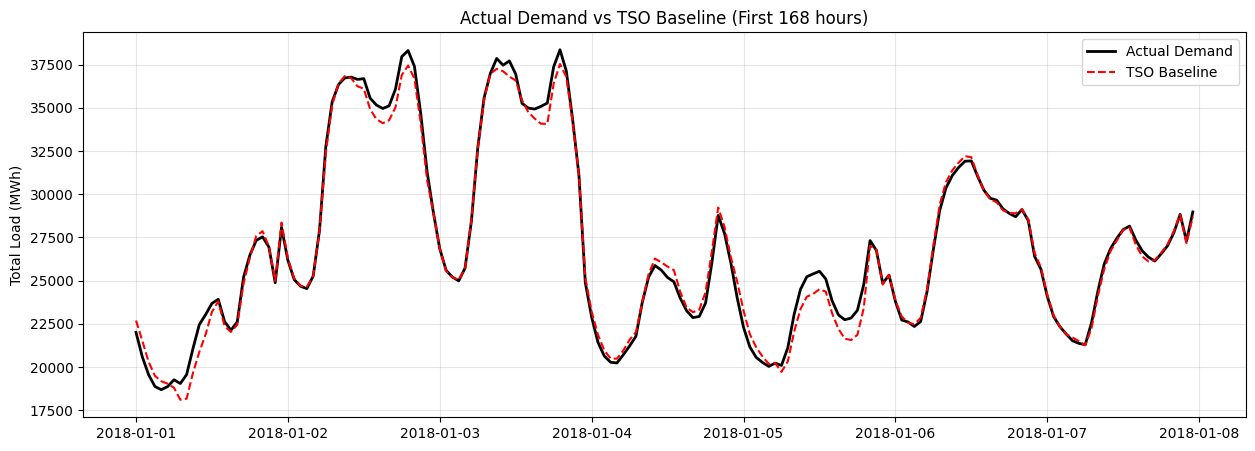

In [2]:
from evaluate import temporal_train_test_split, evaluate_tso_baseline, plot_forecast_vs_actual

X_train, X_test, y_train, y_test = temporal_train_test_split(
    df=df_model,
    target_col="total load actual",
    cutoff_date="2018-01-01 00:00:00+00:00",
)

# TSO metrics are stored and passed to every subsequent model for live comparison
tso_forecast, tso_metrics = evaluate_tso_baseline(
    y_test=y_test,
    energy_csv_path="data/energy_dataset.csv",
)

plot_forecast_vs_actual(y_actual=y_test, y_pred=tso_forecast,
                        model_name="TSO Baseline", window_hours=168)

## 3. XGBoost

--- XGBoost: TIME SERIES CV HYPERPARAMETER SEARCH ---
Running 10 random combinations × 3 folds …
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Cross-validation complete.
Best params:
  subsample: 0.9
  n_estimators: 800
  max_depth: 8
  learning_rate: 0.05
  colsample_bytree: 0.9
CV MAE (best): 1,719.74 MWh

📊 XGBoost — TEST SET 2018
  MAE  : 1,689.99 MWh  (▲1,420.14 vs TSO)
  MAPE : 5.763 %
  RMSE : 2,391.84 MWh


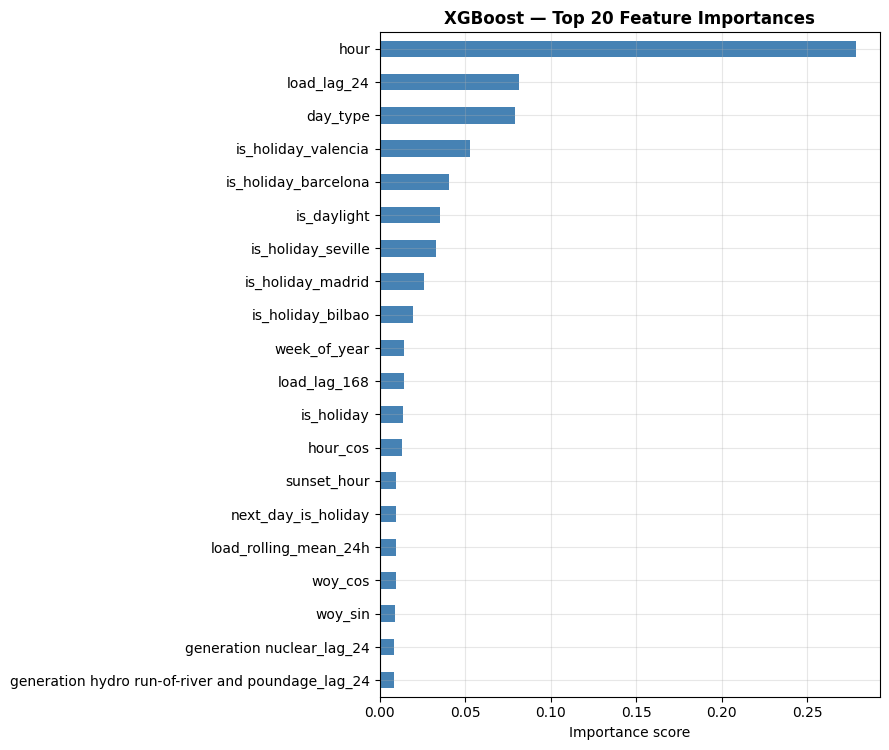

In [5]:
from modeling_ml import tune_xgboost_with_cv, evaluate_xgboost, plot_xgb_feature_importance

best_xgb = tune_xgboost_with_cv(X_train, y_train, n_iter=10)
xgb_preds, xgb_metrics = evaluate_xgboost(best_xgb, X_test, y_test, tso_metrics=tso_metrics)
plot_xgb_feature_importance(best_xgb, X_train, top_n=20)

## 4. LightGBM (Probabilistic)

--- LightGBM: QUANTILE REGRESSION ---
Training median model (α=0.50)…
Training lower bound  (α=0.10)…
Training upper bound  (α=0.90)…

📊 LightGBM Median — TEST SET 2018
  MAE  : 1,603.91 MWh  (▲1,334.06 vs TSO)
  MAPE : 5.482 %
  RMSE : 2,333.29 MWh

--- INTERVAL METRICS ---
  Target coverage : 80%
  PICP            : 52.88%  ⚠️  below target
  MPIW            : 3,036.51 MWh
  Winkler score   : 8,919.92 MWh  (lower = better)


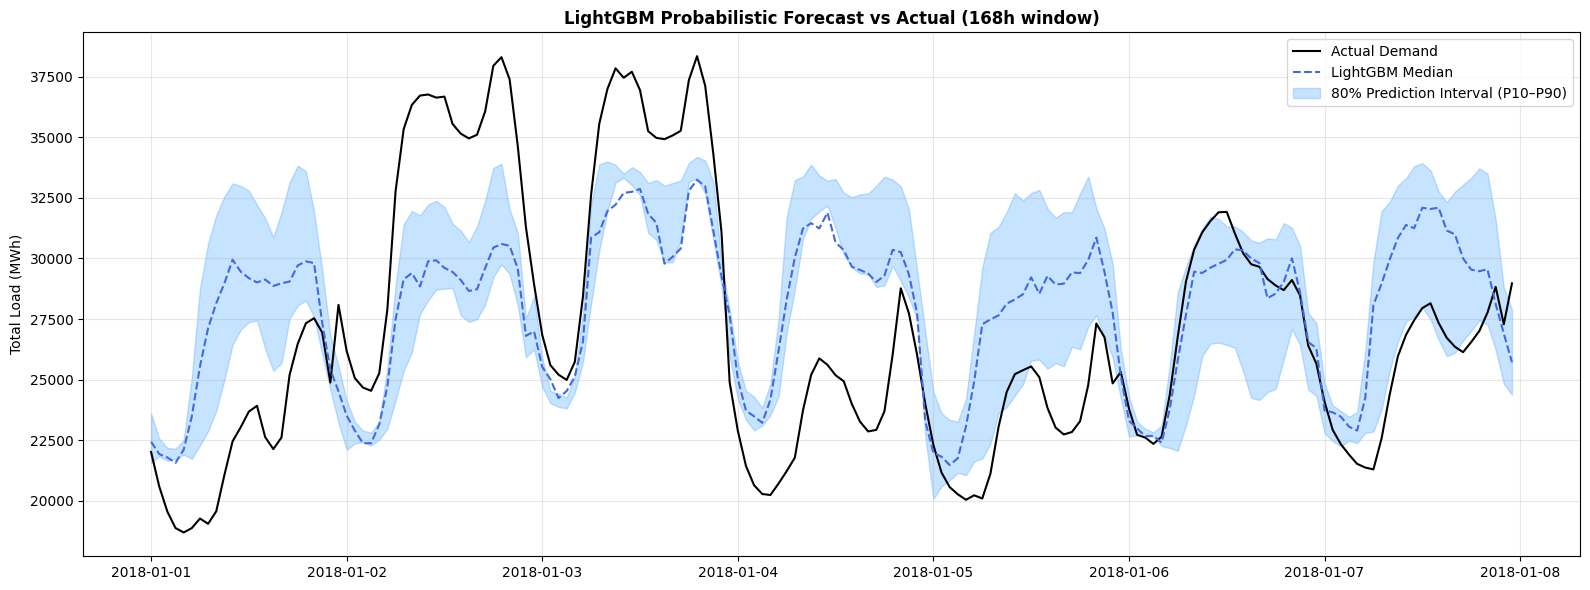

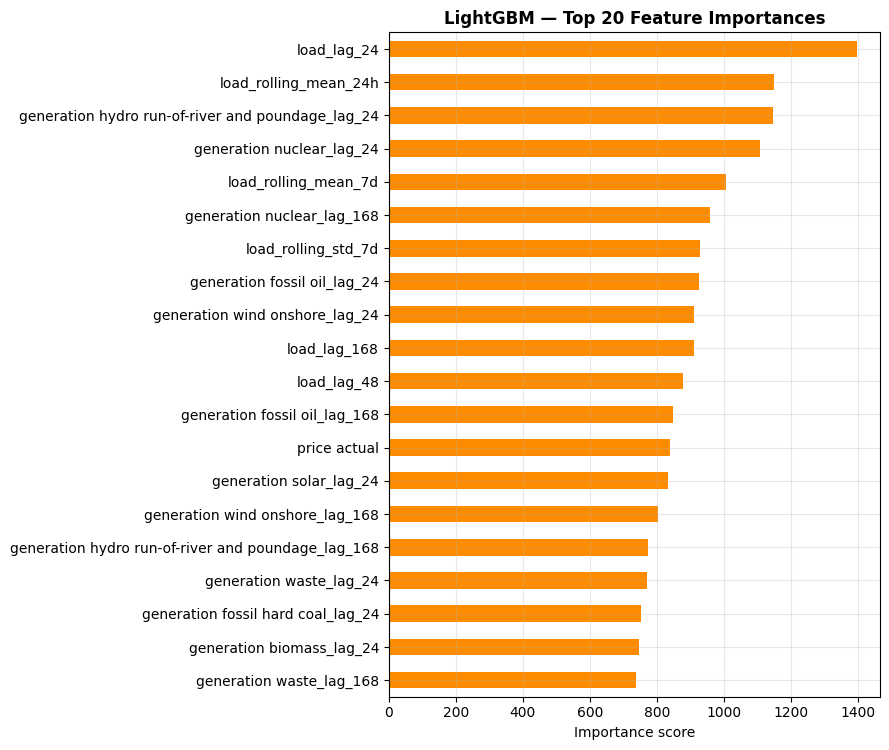

In [6]:
from modeling_ml import (
    train_and_evaluate_lgbm_quantiles,
    evaluate_prediction_intervals,
    plot_lightgbm_intervals,
    plot_lgbm_feature_importance,
)

df_quantiles, best_lgbm, lgbm_metrics = train_and_evaluate_lgbm_quantiles(
    X_train, y_train, X_test, y_test, tso_metrics=tso_metrics,
)

interval_metrics = evaluate_prediction_intervals(df_quantiles, target_coverage=0.80)

plot_lightgbm_intervals(df_quantiles, window_hours=168, start_idx=0)
plot_lgbm_feature_importance(best_lgbm, X_train, top_n=20)

## 5. Alternative Models (CatBoost / MLP / Random Forest)

In [7]:
from modeling_ml import train_alternative_models

alt_preds, alt_metrics = train_alternative_models(
    X_train, y_train, X_test, y_test, tso_metrics=tso_metrics,
)

--- ALTERNATIVE MODELS ---

Training CatBoost…
Training MLP (Neural Network)…
Training Random Forest…

📊 ALTERNATIVE MODELS — TEST SET 2018
Model          |        MAE |  MAPE (%) |       RMSE
----------------------------------------------------
TSO (goal)     |     269.85 |     0.926 |     389.32  ← baseline
----------------------------------------------------
CatBoost       |    1683.82 |     5.748 |    2366.38
MLP            |    2436.16 |     8.345 |    3096.83
RandomForest   |    1684.36 |     5.780 |    2416.20


## 6. Deep Learning Fleet

In [9]:
from modeling_dl import prepare_darts_from_split, train_and_evaluate_deep_learning_fleet

darts_dataset = prepare_darts_from_split(X_train, y_train, X_test, y_test)

predictions, leaderboard = train_and_evaluate_deep_learning_fleet(
    darts_dataset,
    lookback_hours=168,
    horizon=24,
    max_epochs=60,
    tso_metrics=tso_metrics,   # live TSO comparison in leaderboard
)

--- 1. PREPARING DARTS DATA FROM EXISTING TRAIN/TEST SPLIT ---
  Future covariates : 21 columns
  Past covariates   : 106 columns
  Scaling (fit on train, transform test)...
✅ Darts data preparation complete.

🚀 LAUNCHING DEEP LEARNING FLEET


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



──────────────────────────────────────────────────
🧠 TRAINING LSTM
──────────────────────────────────────────────────


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │ 55.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     65 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 55.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 55.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │      0 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │  302 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │ 42.8 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │  1.1 K │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 619 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 619 K                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 2386                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


💾 Saved to saved_models/TFT_model.pt (14 epochs)
Running historical_forecasts for TFT...
✅ TFT | MAE: 1,685.57 MWh | MAPE: 5.824% | RMSE: 2,496.85 MWh
📈 Loss curves → saved_models/TFT_loss_curves.csv

🏆 DEEP LEARNING LEADERBOARD — TEST SET 2018
Model        |  MAE (MWh) |  MAPE (%) |  RMSE (MWh)
------------------------------------------------------------
TSO (goal)   |     269.85 |     0.926 |      389.32  ← baseline
------------------------------------------------------------
N-HiTS       |    1332.74 |     4.618 |     1956.54
GRU          |    1354.01 |     4.598 |     2075.62
N-BEATS      |    1469.06 |     5.126 |     2106.83
TFT          |    1685.57 |     5.824 |     2496.85
LSTM         |    2082.46 |     6.789 |     2831.64
TCN          |    2292.89 |     7.997 |     3097.51

📁 Configs saved → saved_models/fleet_configs.json


### 6.1 Loss Curves

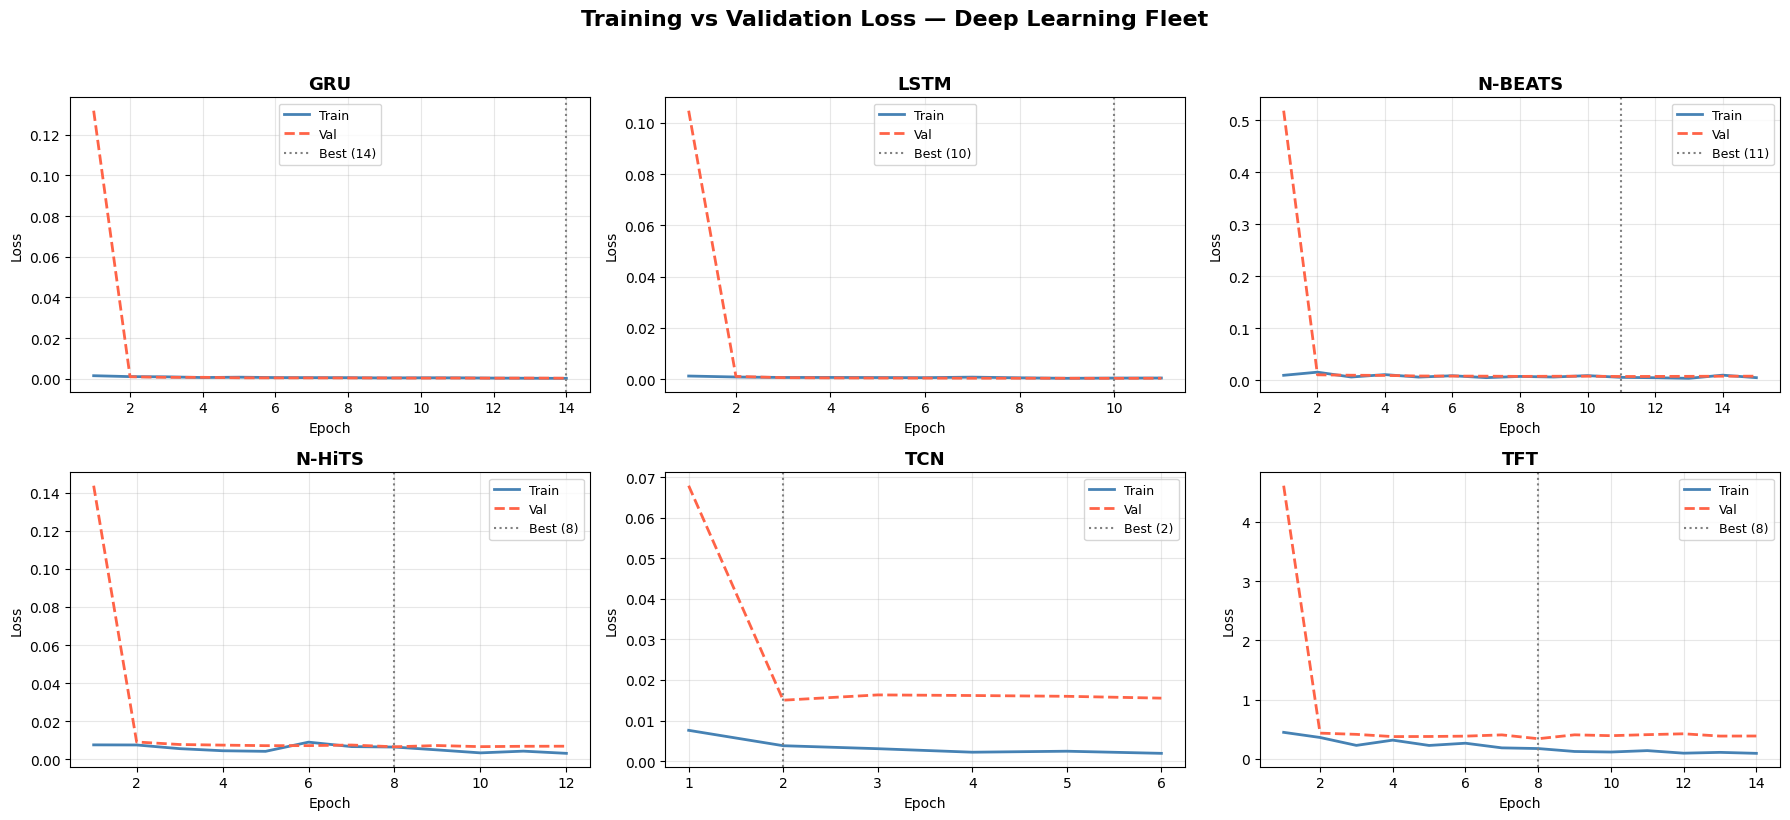

In [10]:
from modeling_dl import plot_saved_loss_curves
plot_saved_loss_curves()

### 6.2 Best Model Visualisation

Best model: N-HiTS


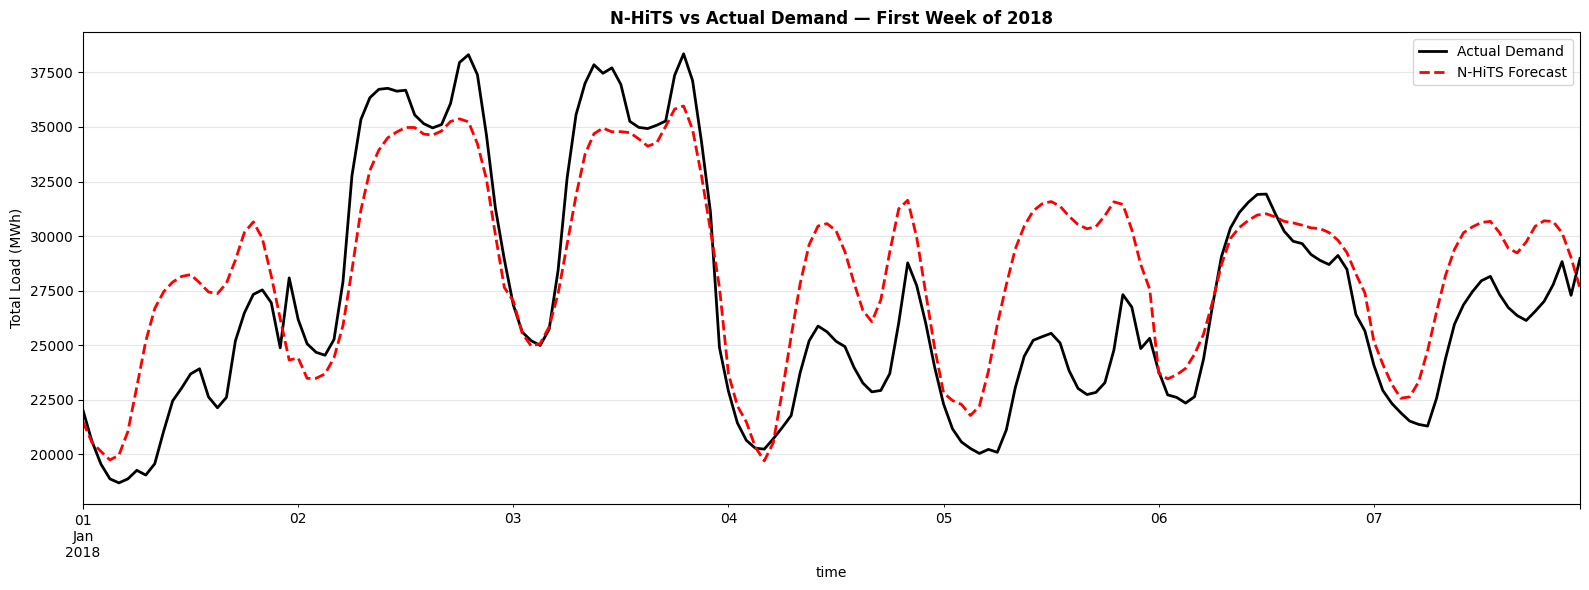

In [11]:
import matplotlib.pyplot as plt

top_name = leaderboard[0][0]
print(f"Best model: {top_name}")

actuals_ts = darts_dataset["test_target_unscaled"]

plt.figure(figsize=(16, 6))
actuals_ts[:168].plot(label="Actual Demand", color="black", linewidth=2)
predictions[top_name][:168].plot(label=f"{top_name} Forecast", color="red", linestyle="--")
plt.title(f"{top_name} vs Actual Demand — First Week of 2018", fontweight="bold")
plt.ylabel("Total Load (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Error Analysis (Best Model)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

top_model_name = leaderboard[0][0]
print(f"Running error analysis for: {top_model_name}")

actuals_df = darts_dataset["test_target_unscaled"].to_dataframe()
preds_df   = predictions[top_model_name].to_dataframe()

error_df = actuals_df.join(preds_df, how="inner", lsuffix="_actual", rsuffix="_pred")
error_df.columns = ["Actual_Demand", "Predicted_Demand"]
error_df["Error"]            = error_df["Predicted_Demand"] - error_df["Actual_Demand"]
error_df["Absolute_Error"]   = error_df["Error"].abs()
error_df["Percentage_Error"] = error_df["Absolute_Error"] / error_df["Actual_Demand"] * 100
error_df["Hour"]             = error_df.index.hour
error_df["DayOfWeek"]        = error_df.index.day_name()
error_df["Date"]             = error_df.index.date
error_df["Season"]           = error_df.index.month.map({
    12:"Winter",1:"Winter",2:"Winter",
    3:"Spring",4:"Spring",5:"Spring",
    6:"Summer",7:"Summer",8:"Summer",
    9:"Autumn",10:"Autumn",11:"Autumn",
})

Running error analysis for: N-HiTS


### 7.1 Worst Days

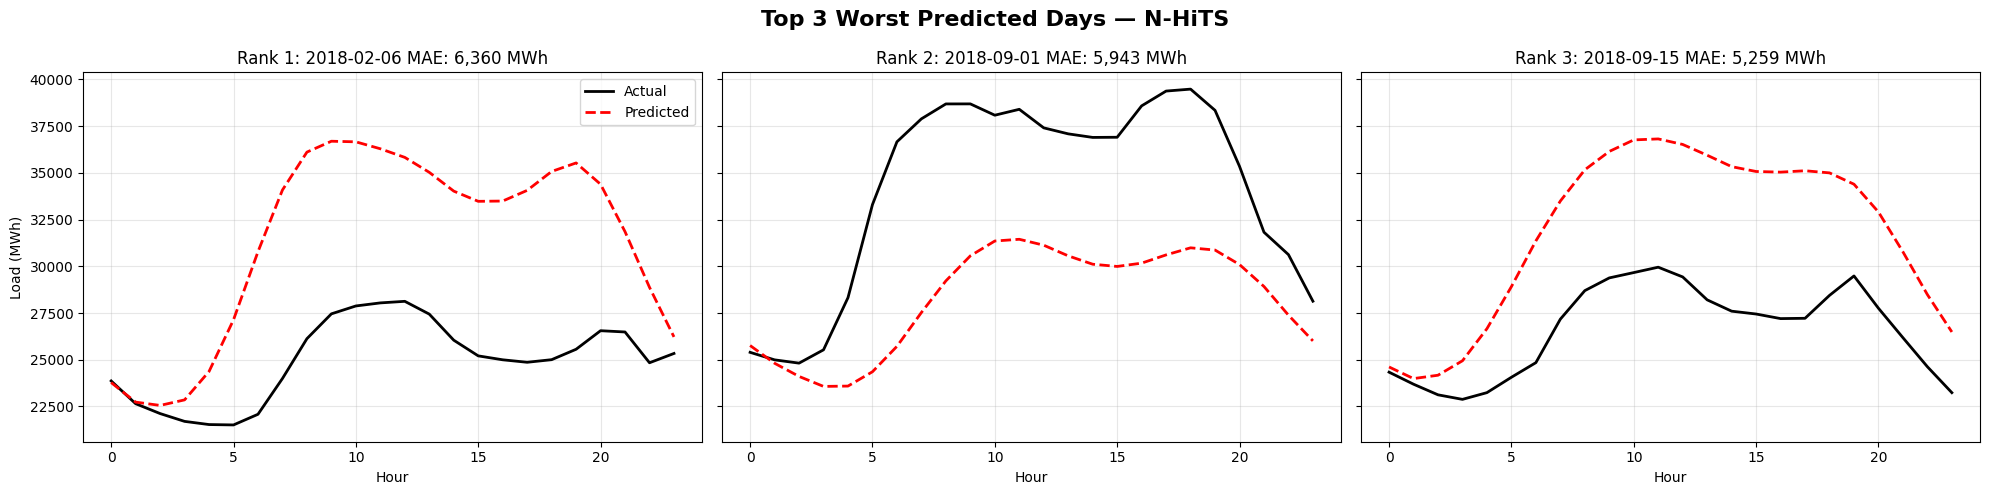

In [13]:
daily_mae = error_df.groupby("Date")["Absolute_Error"].mean().sort_values(ascending=False)
worst_3 = daily_mae.head(3)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
fig.suptitle(f"Top 3 Worst Predicted Days — {top_model_name}", fontsize=16, fontweight="bold")
for i, (date, mae_val) in enumerate(worst_3.items()):
    day_data = error_df[error_df["Date"] == date]
    axes[i].plot(day_data.index.hour, day_data["Actual_Demand"], color="black", lw=2, label="Actual")
    axes[i].plot(day_data.index.hour, day_data["Predicted_Demand"], color="red", linestyle="--", lw=2, label="Predicted")
    axes[i].set_title(f"Rank {i+1}: {date} MAE: {mae_val:,.0f} MWh")
    axes[i].set_xlabel("Hour")
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel("Load (MWh)")
        axes[i].legend()
plt.tight_layout()
plt.show()

### 7.2 Systematic Bias

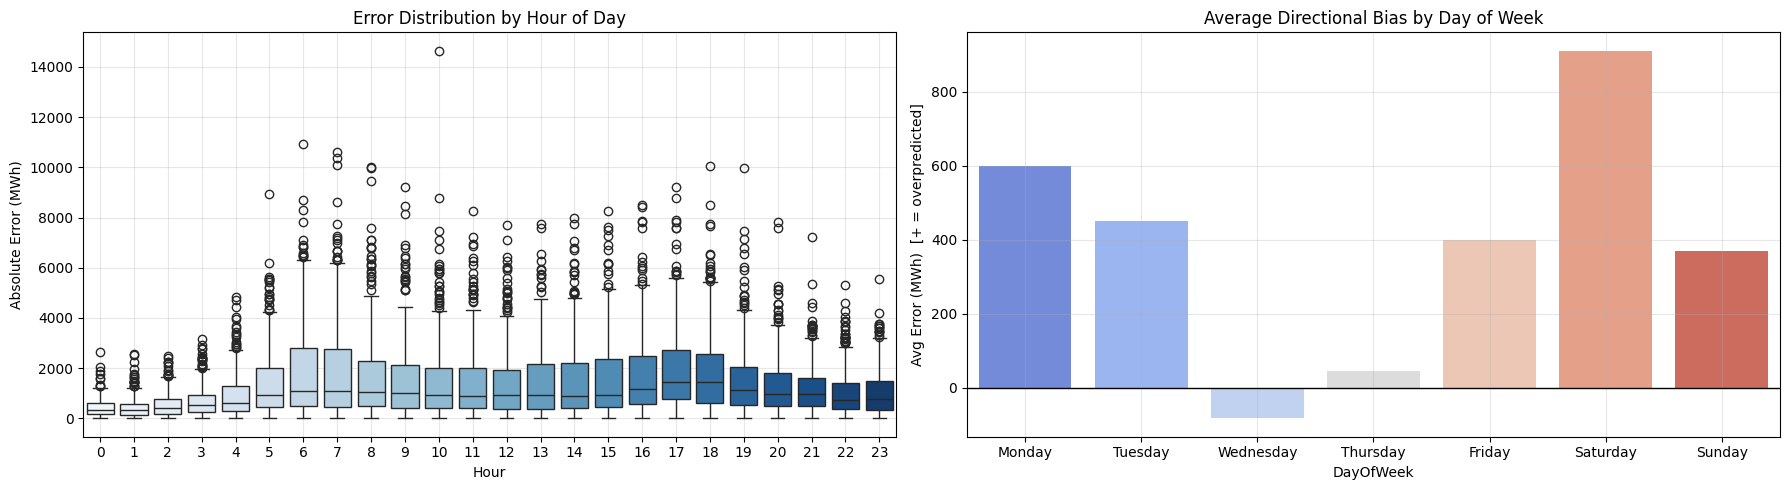

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sns.boxplot(data=error_df, x="Hour", y="Absolute_Error", ax=axes[0], palette="Blues")
axes[0].set_title("Error Distribution by Hour of Day")
axes[0].set_ylabel("Absolute Error (MWh)")
axes[0].grid(True, alpha=0.3)

sns.barplot(data=error_df, x="DayOfWeek", y="Error", order=day_order,
            ax=axes[1], palette="coolwarm", errorbar=None)
axes[1].set_title("Average Directional Bias by Day of Week")
axes[1].set_ylabel("Avg Error (MWh)  [+ = overpredicted]")
axes[1].axhline(0, color="black", lw=1)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Error Drivers

Top 10 features correlated with large errors:
load_lag_24                       0.203645
load_lag_48                       0.194948
is_daylight                       0.178569
load_lag_168                      0.163138
load_rolling_std_7d               0.146487
is_bridge_day                     0.140770
hour                              0.136847
Hour                              0.136847
is_holiday_madrid                 0.116776
generation wind onshore_lag_24    0.111403


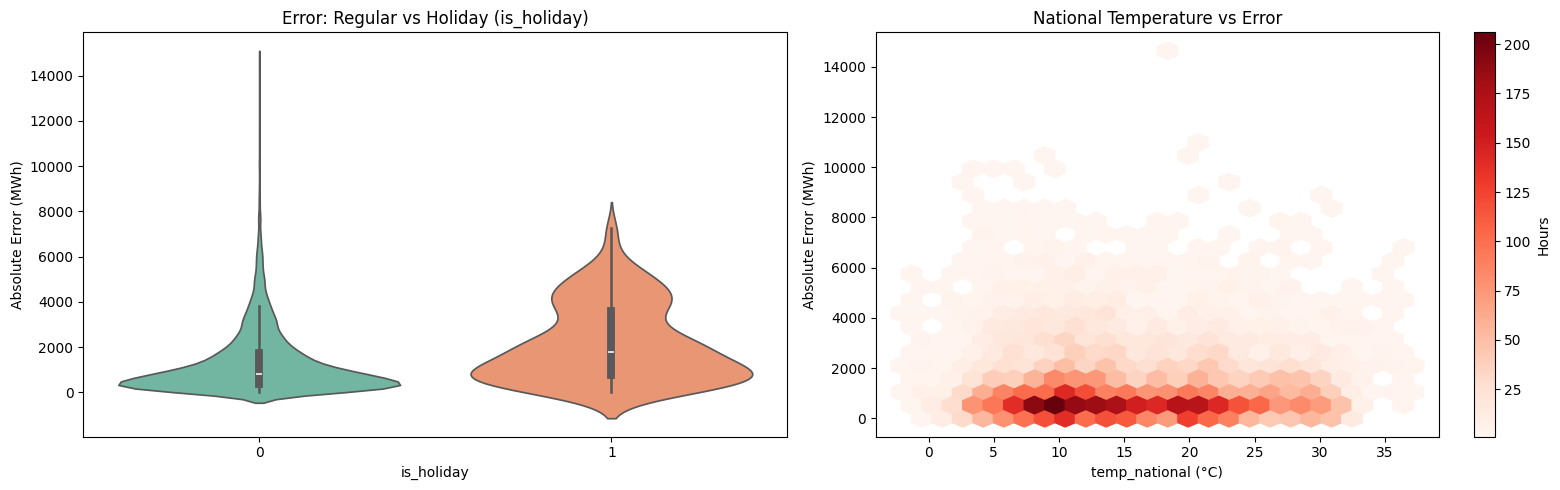

In [15]:
# Join with features for correlation analysis
X_test_naive = X_test.copy()
X_test_naive.index = X_test_naive.index.tz_localize(None)
analysis_df = error_df.join(X_test_naive, how="inner")

numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
error_corr = (
    analysis_df[numeric_cols]
    .corr()["Absolute_Error"]
    .drop(["Error","Absolute_Error","Percentage_Error","Actual_Demand","Predicted_Demand"], errors="ignore")
    .sort_values(ascending=False)
)
print("Top 10 features correlated with large errors:")
print(error_corr.head(10).to_string())

# Holiday impact
hol_cols = [c for c in analysis_df.columns if "holiday" in c.lower()]
temp_cols = [c for c in analysis_df.columns if "temp" in c.lower()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if hol_cols:
    sns.violinplot(data=analysis_df, x=hol_cols[0], y="Absolute_Error", ax=ax1, palette="Set2")
    ax1.set_title(f"Error: Regular vs Holiday ({hol_cols[0]})")
    ax1.set_ylabel("Absolute Error (MWh)")

if temp_cols:
    hb = ax2.hexbin(analysis_df["temp_national"], analysis_df["Absolute_Error"],
                    gridsize=25, cmap="Reds", mincnt=1)
    ax2.set_title("National Temperature vs Error")
    ax2.set_xlabel("temp_national (°C)")
    ax2.set_ylabel("Absolute Error (MWh)")
    fig.colorbar(hb, ax=ax2, label="Hours")

plt.tight_layout()
plt.show()

## 8. Master Comparison Table

In [16]:
# Aggregate all model results into a single leaderboard
import pandas as pd

all_results = {
    "TSO Baseline":  tso_metrics,
    "XGBoost":       xgb_metrics,
    "LightGBM":      lgbm_metrics,
    **alt_metrics,
}

# Add deep learning results
for name, metrics in leaderboard:
    all_results[f"DL: {name}"] = metrics

comparison_df = pd.DataFrame(all_results).T[["MAE", "MAPE", "RMSE"]]
comparison_df = comparison_df.sort_values("MAE")
comparison_df["vs TSO (MAE)"] = comparison_df["MAE"] - tso_metrics["MAE"]

print(comparison_df.round(2).to_string())
display(comparison_df.style
        .background_gradient(subset=["MAE"], cmap="RdYlGn_r")
        .format({"MAE": "{:,.2f}", "MAPE": "{:.3f}", "RMSE": "{:,.2f}", "vs TSO (MAE)": "{:+,.2f}"}))

                  MAE  MAPE     RMSE  vs TSO (MAE)
TSO Baseline   269.85  0.93   389.32          0.00
DL: N-HiTS    1332.74  4.62  1956.54       1062.88
DL: GRU       1354.01  4.60  2075.62       1084.16
DL: N-BEATS   1469.06  5.13  2106.83       1199.21
LightGBM      1603.91  5.48  2333.29       1334.06
CatBoost      1683.82  5.75  2366.38       1413.97
RandomForest  1684.36  5.78  2416.20       1414.51
DL: TFT       1685.57  5.82  2496.85       1415.72
XGBoost       1689.99  5.76  2391.84       1420.14
DL: LSTM      2082.46  6.79  2831.64       1812.61
DL: TCN       2292.89  8.00  3097.51       2023.04
MLP           2436.16  8.34  3096.83       2166.31


,MAE,MAPE,RMSE,vs TSO (MAE)
TSO Baseline,269.85,0.926,389.32,+0.00
DL: N-HiTS,"1,332.74",4.618,"1,956.54","+1,062.88"
DL: GRU,"1,354.01",4.598,"2,075.62","+1,084.16"
DL: N-BEATS,"1,469.06",5.126,"2,106.83","+1,199.21"
LightGBM,"1,603.91",5.482,"2,333.29","+1,334.06"
CatBoost,"1,683.82",5.748,"2,366.38","+1,413.97"
RandomForest,"1,684.36",5.780,"2,416.20","+1,414.51"
DL: TFT,"1,685.57",5.824,"2,496.85","+1,415.72"
XGBoost,"1,689.99",5.763,"2,391.84","+1,420.14"
DL: LSTM,"2,082.46",6.789,"2,831.64","+1,812.61"
